# 2. trotterized two qubit of Ising

#### Trotterized Dynamics of a Two-Qubit Ising Model

We consider $H = H_{ZZ} + H_X = -J Z_0Z_1 - h(X_0+X_1)$

Since $[H_{ZZ},H_X]\neq 0$

the exact time evolution cannot be factorized into independent 
$(ZZ)$ and $(X)$ evolutions. We approximate it using the first-order Lie–Trotter formula

$U_r(t)=
\left[
e^{-iH_{ZZ}t/r}
e^{-iH_Xt/r}
\right]^r.$

For one time slice $(\Delta t=t/r)$, $e^{-iH_X\Delta t}=
RX_0(-2h\Delta t)RX_1(-2h\Delta t)$
and
$e^{-iH_{ZZ}\Delta t}=
RZZ(-2J\Delta t)$

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import qiskit

from scipy.linalg import expm
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp
print("Qiskit version: ", qiskit.__version__)

Qiskit version:  2.2.3


In [23]:
%load_ext autoreload
%autoreload 2
    
from Ising_sim_helper.operators import (
    KET_00, KET_01, KET_10, KET_11,
    COMPUTATIONAL_BASIS, BASIS_LABELS,
    I, X, Y, Z, X0, X1, Z0, Z1,
    ZZ, MZ,
)

In [25]:
from Ising_sim_helper.dynamics import (
    build_hamiltonian,
    exact_state,
    expectation_value,
    state_fidelity,
    basis_probabilities,
    analytic_energy_spectrum,
)

In [33]:
from Ising_sim_helper.circuits import (
    first_order_trotter_circuit,
    second_order_trotter_circuit,
    statevector_from_circuit,
)

## 2.1 Trotterized decomposition

In [83]:
J = 1.0
h = 0.6
H = -J * ZZ - h * (X0 + X1)
psi_0 = exact_state(time=0, hamiltonian=H, initial_state=KET_00)
assert np.allclose(psi_0, KET_00)

In [84]:
circuit_first_order = first_order_trotter_circuit(
    time = 1.0, J=J, h=h, n_steps=3
)
print(circuit_first_order)

     ┌──────────┐               ┌──────────┐               ┌──────────┐»
q_0: ┤ Rx(-0.4) ├─■─────────────┤ Rx(-0.4) ├─■─────────────┤ Rx(-0.4) ├»
     ├──────────┤ │ZZ(-0.66667) ├──────────┤ │ZZ(-0.66667) ├──────────┤»
q_1: ┤ Rx(-0.4) ├─■─────────────┤ Rx(-0.4) ├─■─────────────┤ Rx(-0.4) ├»
     └──────────┘               └──────────┘               └──────────┘»
«                    
«q_0: ─■─────────────
«      │ZZ(-0.66667) 
«q_1: ─■─────────────
«                    


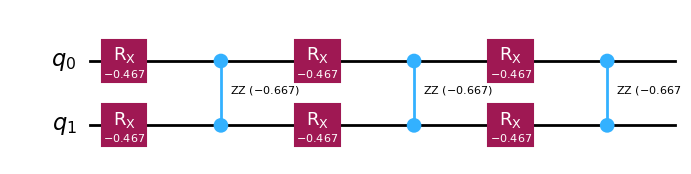

In [46]:
circuit_first_order.draw("mpl")

In [47]:
psi_trotter = statevector_from_circuit(circuit_first_order)
print(psi_trotter)

[ 0.20633993+0.69084936j  0.13607784+0.39300057j  0.13607784+0.39300057j
 -0.33396238-0.15062162j]


In [85]:
def one_step_state_by_hand(time, J, h):
    c = np.cos(h * time)
    s = np.sin(h * time)

    phase_aligned = np.exp(1j * J * time)
    phase_anti = np.exp(-1j * J * time)

    return np.array(
        [
            phase_aligned * c**2,
            1j * phase_anti * c * s,
            1j * phase_anti * c * s,
            -phase_aligned * s**2,
        ],
        dtype=complex,
    )


psi_hand = one_step_state_by_hand(time=1.0, J=1.0, h=0.6)
psi_trotter= first_order_trotter_circuit(time = 1.0, J=J, h=h, n_steps=1)
psi_qiskit = statevector_from_circuit(psi_trotter)

print("Hand calculation:")
print(psi_hand)

print("\nQiskit:")
print(psi_qiskit)

assert np.allclose(psi_hand, psi_qiskit)


Hand calculation:
[ 0.36804252+0.57319226j  0.39214192+0.25179143j  0.39214192+0.25179143j
 -0.17225979-0.26827872j]

Qiskit:
[ 0.36804252+0.57319226j  0.39214192+0.25179143j  0.39214192+0.25179143j
 -0.17225979-0.26827872j]


## 2.2 fidelity and expectation


$F = \braket{\psi_{\rm exact}|\psi_{\rm Trotter}}$

In [86]:
psi_exact = exact_state(time=1.0, hamiltonian=H, initial_state=KET_00)
psi_trotter = statevector_from_circuit(first_order_trotter_circuit(time=1.0, J=J, h=h, n_steps=1))

fidelity = state_fidelity(psi_exact, psi_trotter)

mz_exact = expectation_value(psi_exact, MZ)
mz_trotter = expectation_value(psi_trotter, MZ)

print("Fidelity:", fidelity)
print("Exact Mz:", mz_exact)
print("Trotter Mz:", mz_trotter)

Fidelity: 0.7585283804903903
Exact Mz: 0.5434016277064765
Trotter Mz: 0.3623577544766736


## 2.3 Convergence Comparision

In [87]:
final_time = 2.0
step_numbers = [1, 2, 4, 8, 16]

psi_exact_final = exact_state(
    time=final_time, hamiltonian=H, initial_state=KET_00
)

results = []

for n_steps in step_numbers:
    circuit = first_order_trotter_circuit(
        final_time,
        J,
        h,
        n_steps,
    )

    psi_trotter_final = statevector_from_circuit(circuit)

    fidelity = state_fidelity(
        psi_exact_final,
        psi_trotter_final,
    )

    mz_trotter = expectation_value(
        psi_trotter_final,
        MZ,
    )

    mz_exact = expectation_value(
        psi_exact_final,
        MZ,
    )

    results.append(
        {
            "steps": n_steps,
            "fidelity": fidelity,
            "infidelity": 1.0 - fidelity,
            "mz_error": abs(mz_trotter - mz_exact),
            "circuit_depth": circuit.depth(),
            "gate_count": circuit.size(),
        }
    )

for result in results:
    print(result)

{'steps': 1, 'fidelity': 0.2247233216187371, 'infidelity': 0.7752766783812629, 'mz_error': 1.1636592289238878, 'circuit_depth': 2, 'gate_count': 3}
{'steps': 2, 'fidelity': 0.9317106530390449, 'infidelity': 0.06828934696095512, 'mz_error': 0.06654307812642235, 'circuit_depth': 4, 'gate_count': 6}
{'steps': 4, 'fidelity': 0.9971108380214128, 'infidelity': 0.0028891619785872402, 'mz_error': 0.039173490949048984, 'circuit_depth': 8, 'gate_count': 12}
{'steps': 8, 'fidelity': 0.9998343272814028, 'infidelity': 0.00016567271859724286, 'mz_error': 0.010580313824032461, 'circuit_depth': 16, 'gate_count': 24}
{'steps': 16, 'fidelity': 0.9999888787493728, 'infidelity': 1.1121250627188495e-05, 'mz_error': 0.0026859465035098395, 'circuit_depth': 32, 'gate_count': 48}


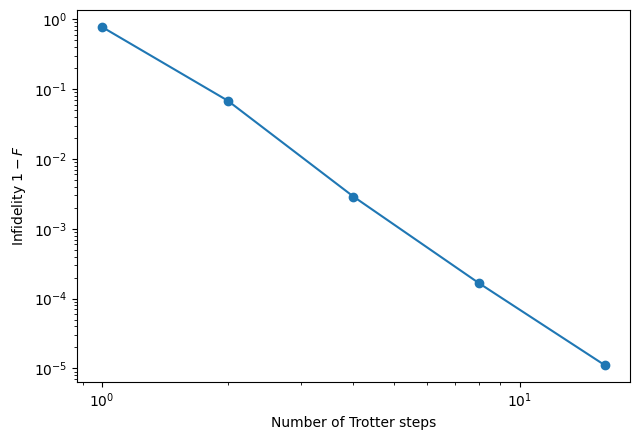

In [88]:
steps = np.array(
    [result["steps"] for result in results]
)

infidelities = np.array(
    [result["infidelity"] for result in results]
)

plt.figure(figsize=(6.5, 4.5))

plt.loglog(
    steps,
    infidelities,
    marker="o",
)

plt.xlabel("Number of Trotter steps")
plt.ylabel(r"Infidelity $1-F$")
plt.tight_layout()
plt.show()

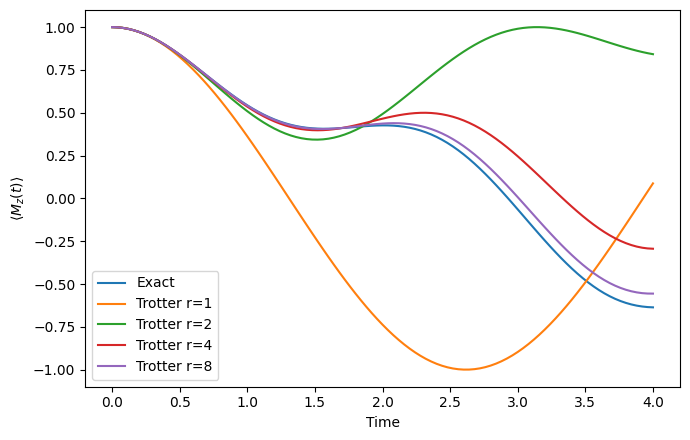

In [89]:
times = np.linspace(0.0, 4.0, 101)

mz_exact_values = []

for time in times:
    psi = exact_state(time=time, hamiltonian=H, initial_state=KET_00)
    mz_exact_values.append(
        expectation_value(psi, MZ)
    )

plt.figure(figsize=(7, 4.5))

plt.plot(
    times,
    mz_exact_values,
    label="Exact",
)

for n_steps in [1, 2, 4, 8]:
    mz_trotter_values = []

    for time in times:
        psi_circuit = first_order_trotter_circuit(
            time,
            J,
            h,
            n_steps,
        )
        psi = statevector_from_circuit(psi_circuit)
        mz_trotter_values.append(
            expectation_value(psi, MZ)
        )

    plt.plot(
        times,
        mz_trotter_values,
        label=f"Trotter r={n_steps}",
    )

plt.xlabel("Time")
plt.ylabel(r"$\langle M_z(t)\rangle$")
plt.legend()
plt.tight_layout()
plt.show()

In [90]:

H_qiskit = SparsePauliOp.from_list(
    [
        ("ZZ", -J),
        ("XI", -h),
        ("IX", -h),
    ]
)

print('H_qiskit: ', H_qiskit)
print('H: ', H)

assert np.allclose(H_qiskit.to_matrix(),H)

H_qiskit:  SparsePauliOp(['ZZ', 'XI', 'IX'],
              coeffs=[-1. +0.j, -0.6+0.j, -0.6+0.j])
H:  [[-1. +0.j -0.6+0.j -0.6+0.j -0. +0.j]
 [-0.6+0.j  1. -0.j -0. +0.j -0.6+0.j]
 [-0.6+0.j -0. +0.j  1. -0.j -0.6+0.j]
 [-0. +0.j -0.6+0.j -0.6+0.j -1. +0.j]]
